# 5장 1강: 배깅과 랜덤포레스트

## 실습 목표
이번 실습에서는 **Ames Housing** 데이터를 이용하여 배깅과 랜덤포레스트의 핵심 원리를 확인합니다.

- 하나의 의사결정나무와 여러 나무를 모은 배깅의 차이를 확인합니다.
- 배깅에서 여러 회귀 모델의 예측을 평균내는 이유를 이해합니다.
- 랜덤포레스트의 부트스트랩과 피처 무작위 선택 개념을 확인합니다.
- OOB Score와 Feature Importance를 확인합니다.
- 여러 나무를 평균낼 때 분산이 줄어드는 이유를 설명합니다.

> 교안에 나온 범위만 사용합니다.

## 실습 환경 / 데이터
- Python, pandas, numpy, matplotlib, scikit-learn
- 데이터: `Ames_Housing.csv`
- 예측 대상: `SalePrice`

사용 특성:
`OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`,
`2ndFlrSF`, `FullBath`, `TotRmsAbvGrd`, `YearBuilt`, `YearRemodAdd`, `Fireplaces`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.metrics import r2_score

house = pd.read_csv("Ames_Housing.csv")

features = [
    "OverallQual","GrLivArea","GarageCars","GarageArea",
    "TotalBsmtSF","1stFlrSF","2ndFlrSF","FullBath",
    "TotRmsAbvGrd","YearBuilt","YearRemodAdd","Fireplaces"
]

X = house[features]
y = house["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
display(X.isna().sum().to_frame("missing"))

Train: (1168, 12)
Test: (292, 12)


,missing
OverallQual,0
GrLivArea,0
GarageCars,0
GarageArea,0
TotalBsmtSF,0
1stFlrSF,0
2ndFlrSF,0
FullBath,0
TotRmsAbvGrd,0
YearBuilt,0


# 필수 1. 하나의 나무와 Bagging 비교

## 문제 1. Decision Tree 하나를 학습하세요.
1. `DecisionTreeRegressor(random_state=42)` 사용
2. Train 학습
3. Train/Test 예측
4. Train R², Test R² 계산
5. 두 점수 차이 해석

In [2]:
# TODO

dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

train_pred = dt_model.predict(X_train)
test_pred = dt_model.predict(X_test)

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

print(f'train pred : {train_r2:.4f}')
print(f'test pred : {test_r2:.4f}')

train pred : 0.9999
test pred : 0.7939


- Train이 1에 가깝다는 것의 의미

    - 일반적으로 R²이 1에 가깝다는 것은 모델이 충분히 해당 데이터에 대한 설명력을 가지고 있다는 것이지만, 

    - 지나치게 성능이 높은 경우 과적합을 의심하여 추가적인 검증이 필요하다.


### Q1. Train R²는 매우 높은데 Test R²가 더 낮다면 무엇을 의미하나요?

**답변:** 

- 이는 하나의 나무가 학습 데이터 변화에 민감한 분산이 큰 모델임을 보여준다.

- Decision Tree의 한 그루는 불안정할 수 있다.

## 문제 2. Bagging을 적용하세요.
1. 기본 모델은 `DecisionTreeRegressor(random_state=42)`
2. `BaggingRegressor`
3. `n_estimators=50`
4. `random_state=42`
5. Test R² 계산
6. `max_features="sqrt`
7. Decision Tree 하나와 비교

In [3]:
# TODO

# 모델 학습
dt_model = DecisionTreeRegressor(random_state=42)
bagging_model = BaggingRegressor(n_estimators=50, random_state=42)

dt_model.fit(X_train, y_train)
bagging_model.fit(X_train, y_train)

# 모델 예측
dt_pred = dt_model.predict(X_test)
bagging_pred = bagging_model.predict(X_test)


# 모델 성능
dt_r2 = r2_score(y_test, dt_pred)
bagging_r2 = r2_score(y_test, bagging_pred)

print(f"Decison Tree r2-score : {dt_r2:.4f}")
print(f"Bagging r2-score : {bagging_r2:.4f}")

Decison Tree r2-score : 0.7939
Bagging r2-score : 0.8893


- 배깅, 나무를 50개로 평균한다는 것의 의미

    - 어떤 트리가 특정 주택을 높게 예측하고 다른 트리가 낮게 예측하면 평균에서 오류가 일부 상쇄될 수 있다.

    - 다만, 여러 트리가 모두 같은 방향으로 크게 틀리는 경우 평균을 해도 오류가 남는다.
    - 따라서 무조건 모델 수만 늘리면 오류를 해결할 수 있는 것은 아니다.


### Q2. 왜 각 나무를 서로 다른 부트스트랩 샘플로 학습하나요?

**답변:** 

- 완전히 같은 데이터로 여러 나무를 구성하게 되면 모델이 비슷한 학습을 보이기 때문에 앙상블 효과가 적어진다.

- 부트스트랩으로 복원추출 후 학습 데이터셋을 조금씩 바꾸면 나무마다 다른 오류 패턴을 학습하고 평균을 내는 과정에서 오류가 일부 상쇄될 가능성이 있음.

# 필수 2. Random Forest의 OOB Score와 Feature Importance

## 문제 1. OOB Score를 확인하세요.
1. `RandomForestRegressor`
2. `n_estimators=100`
3. `bootstrap=True`
4. `oob_score=True`
5. `random_state=42`
6. Test R²와 `oob_score_` 출력

In [4]:
# TODO

rf_model = RandomForestRegressor(
    n_estimators=100, 
    bootstrap=True, 
    oob_score=True, 
    random_state=42
    )

rf_model.fit(X_train, y_train)
pred = rf_model.predict(X_test)


test_r2 = r2_score(y_test, pred)

print(f"Test r2 : {test_r2:.4f}")
print(f"OOB Score : {rf_model.oob_score_:.4f}")

Test r2 : 0.8901
OOB Score : 0.8190


- 각 Train 표본의 OOB 예측을 따로 모은다.
    - -> 어떤 Train 주택 A를 예측할 때 A를 한번도 뽑지 않은 나무들만 사용한다.
    - 1, 4, 7번 나무가 A를 학습하지 않았다면 A의 예측 평균을 사용한다.

- Test R²은 0.89 : 별도 100개의 나무 전체의 평균
- OOB Score : 각 Train 쵸본을 학습하지 않은 나무들의 표본 예측 결과

```math
P(\mathrm{OOB}) = \left(1-\frac1N\right)^N\approx e^{-1}\approx0.368
```

- OOB가 0.83이라는 것의 의미
    - OOB 예측의 제곱오차 합이 Train 실제 평균 가격을 예측하는 기준보다 83% 작다.



### Q3. OOB 샘플은 무엇인가요?

**답변:**
- OOB 샘플은 부트스트랩 샘플링에서 한 번도 선택되지 않은 데이터



### Q4. OOB Score가 교차검증을 완전히 대체하나요?

**답변:**
- 완전히 대체하지는 않는다. OOB는 편리한 추정치를 산출하지만,

- 데이터가 적은 상황, 신뢰도가 더 높게 필요한 상황이라면 교차검증과 함께 쓰는 것이 일반적이다.

## 문제 2. Feature Importance를 확인하세요.
1. `feature_importances_` 사용
2. 특성명과 중요도 DataFrame 생성
3. 내림차순 정렬
4. 막대그래프
5. 가장 높은 중요도 특성 확인

,Feature,importance
0,OverallQual,0.568166
1,GrLivArea,0.145061
4,TotalBsmtSF,0.059064
5,1stFlrSF,0.047472
6,2ndFlrSF,0.044405
3,GarageArea,0.033536
9,YearBuilt,0.031569
10,YearRemodAdd,0.022596
2,GarageCars,0.017413
8,TotRmsAbvGrd,0.012278


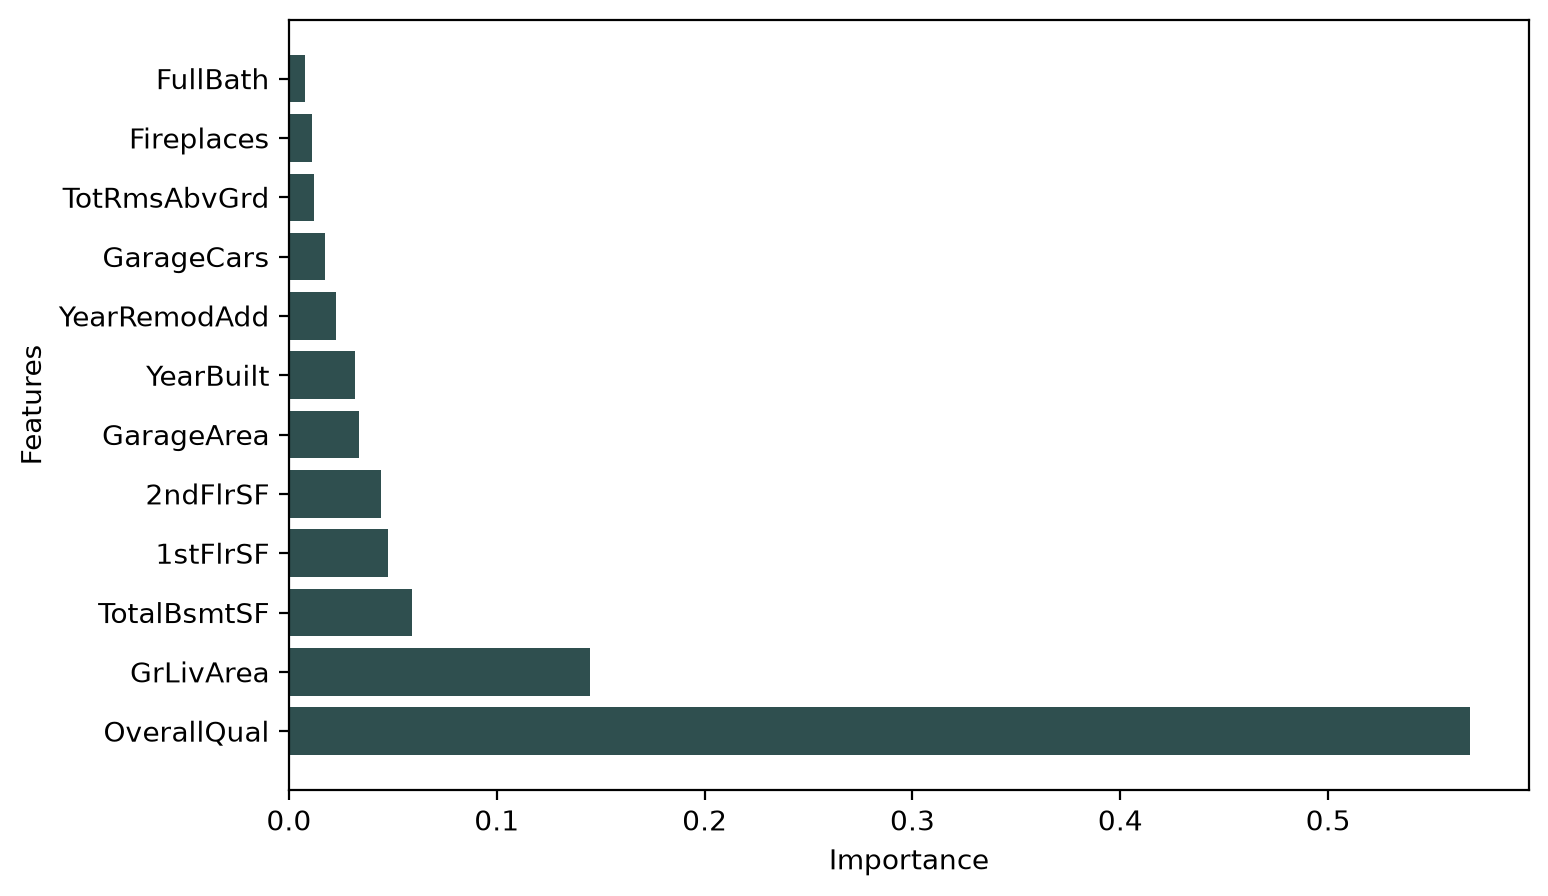

In [5]:
# TODO

importance = pd.DataFrame({
    "Feature" : X_train.columns,
    "importance" : rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

display(importance)

# 막대그래프
plt.figure(figsize=(8, 5))

plt.barh(importance['Feature'], importance["importance"], color="darkslategrey")

plt.xlabel("Importance")
plt.ylabel('Features')

plt.show()

> **해석 1:**   
    - `OverallQual`의 막대가 0.57까지 나타나있고, GrLivArea가 0.15라는 것은   
    - 품질과 지상면적에 약 72% 정도의 설명력을 가지고 있다는 것으로 해석할 수 있음   
    - 이 두 가지 지표로 전페 중요도의 72%정도 이기 떄문에 가격변동(Y)의 72%는 중요한 참고 데이터로 사용함   
    - 단 R2이 72%정도다라고 설명하는 것은 적절하지 않음

- 중요도 0.57을 어떻게 해석할 수 있는지?
    - 가장 정확한 정의는 랜덤포레스트의 불순도 기반 중요도에서 OvallQual(품질)이 약 57%정도 차지했다.

- 잘못된 해석
    - 품질이 집값의 57%를 결정한다.
    - 품질 1등급을 올리면 가격이 23% 상승한다.

- 낮은 중요도는 쓸모없는 변수라는 것을 의미하는가?
    - 아니다
    - 해당 모겔이 예측할 때, 조금 덜 힌트를 얻었다는 식으로 설명할 수 있음

- 중요도 해석 한계점
    - 불순도 기반 중요도가 가능한 분할 지점이 많은 특성에 유리하게 작용
    - 따라서 상관된 특성끼리 중요도가 나뉘거나 쏠리는 현상이 있을 수 있음

> **해석 2:**   
    - 현재 이 모델에서 중요도는 품질 등급과 지상면적이 가장 크다.   
    - 이 부분은 이 입력구성과 학습설정에서 모델이 예측을 위해 사용한 분할 정보의 상대적 기여를 의미한다.

---

### Q5. Feature Importance가 높다는 것이 그 변수가 주택가격의 원인이라는 뜻인가요?

**답변:**

- 아니다.
- 중요도가 높다라는 것의 올바른 해석은 현재 모델이(설정 상태) 예측을 할 때 많이 활용했다는 의미  

# 과제 1. 나무 수와 예측 안정성 확인

`tree_counts = [1, 10, 50, 100]`을 사용하세요.

각 나무 수에서:
1. RandomForestRegressor 생성
2. `bootstrap=True`, `random_state=42`
3. Train 학습
4. Test R² 계산
5. DataFrame 정리
6. 나무 수에 따른 성능 변화 확인
7. 여러 예측의 평균과 분산 감소 관계 설명

,estimators,r2-score
0,1,0.7429
1,10,0.8836
2,50,0.8895
3,100,0.8901


<function matplotlib.pyplot.show(close=None, block=None)>

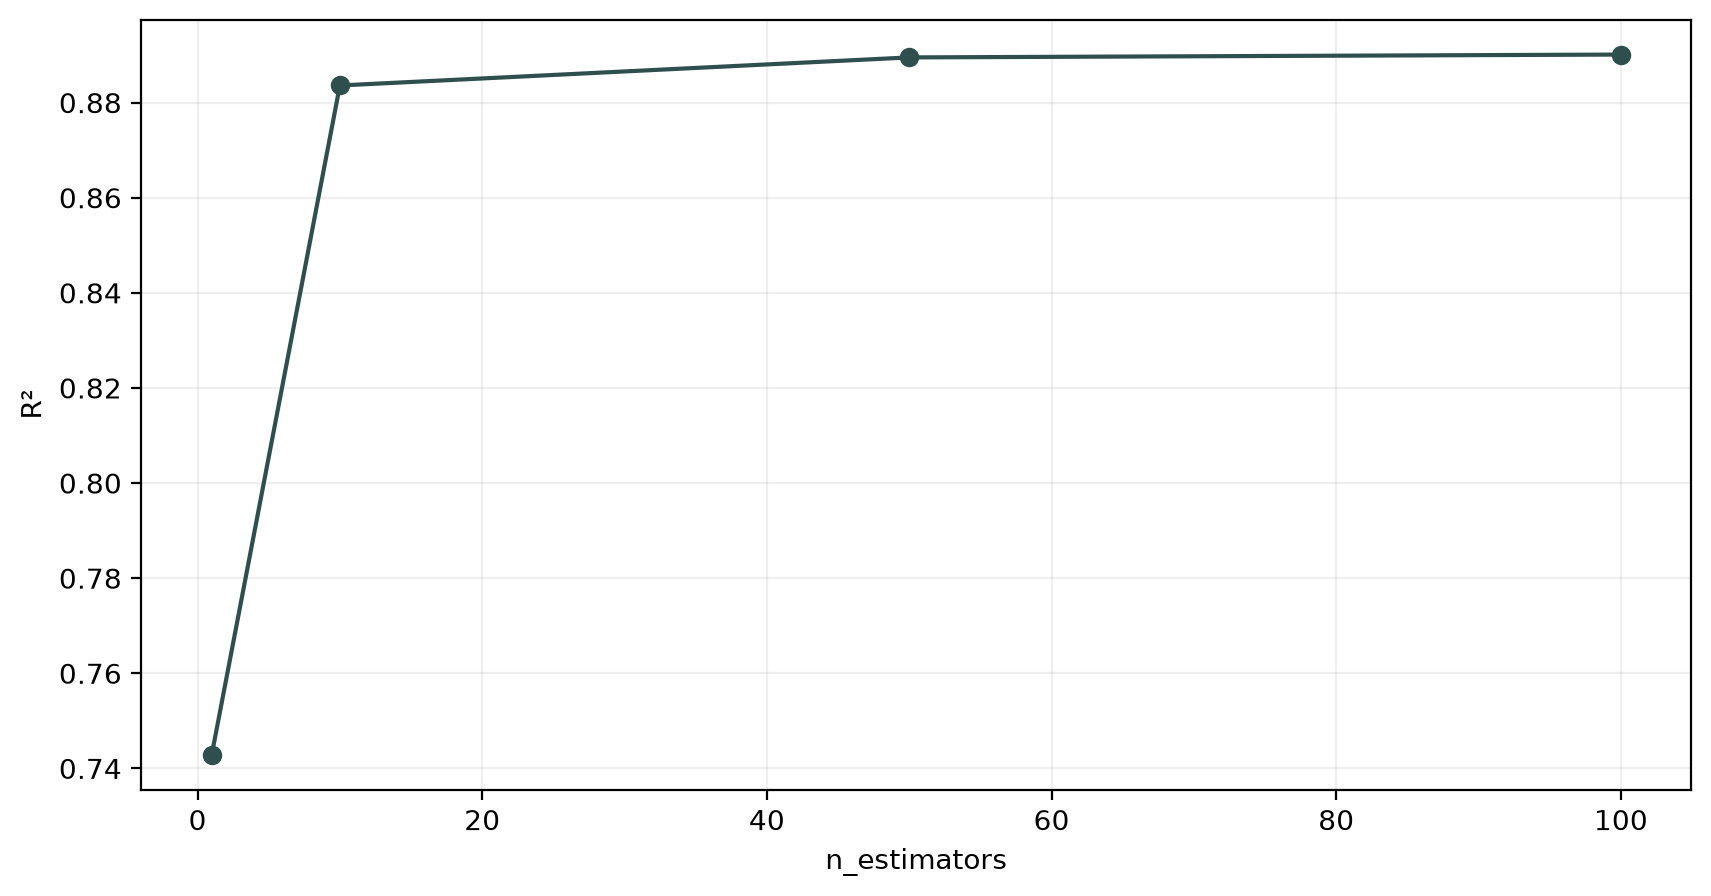

In [6]:
# TODO

tree_counts = [1, 10, 50, 100]


r2_list = []

for tree_count in tree_counts:
    rf_model = RandomForestRegressor(
        n_estimators=tree_count, 
        bootstrap=True, 
        random_state=42
    )

    rf_model.fit(X_train, y_train)

    pred = rf_model.predict(X_test)

    r2 = r2_score(y_test, pred)

    r2_list.append(r2)

result = pd.DataFrame({
    "estimators" : tree_counts,
    "r2-score" : r2_list
}).round(4)

display(result)

# estimators 시각화
plt.figure(figsize=(10, 5))

plt.plot(result['estimators'], result['r2-score'], color="darkslategrey", marker='o')


plt.xlabel('n_estimators')
plt.ylabel('R²')
plt.grid(alpha=0.2)

plt.show

### Q6. 나무 수를 늘리면 왜 예측이 더 안정적으로 변하나요?

**답변:** 

- 랜덤포레스트는 여러 개의 트리의 예측 결과의 평균을 내어 최종 예측을 진행한다.

- 나무 수가 적을 수록 나무의 개별 예측 결과가 전체 예측에 큰 영향을 미칠 수 있으며
- 나무 수가 증가할 수록 여러 나무의 예측결과를 평균 또는 다수결로 결정하므로 개별나무의 영향을 줄일 수 있으며 분산이 감소하고 예측결과가 더 안정적으로 변한다.

### Q7. 나무 수를 계속 늘리면 분산이 무한히 0으로 줄어드나요?

**답변:**

- 아니요
- 랜덤포레스트는 여러 나무의 예측결과를 평균내기 때문에 분산을 감소시키지만, 분산 감소에는 한계가 있다.

# 실습 마무리
1. 부트스트랩 샘플링은 어떤 방식인가요?
    - 원본 데이터셋에서 중복을 허용하여 같은 크기의 샘플을 추출

2. Bagging 회귀에서는 여러 모델의 예측을 어떻게 합치나요?
    - 여러 모델의 예측값의 평균

3. Random Forest가 Bagging에 추가하는 무작위성은 무엇인가요?
    - 각 트리 분할에서 일부 피처만 무작위 후보로 사용

4. OOB 샘플은 평균적으로 약 몇 %인가요?
    - 약 36.8%

5. Feature Importance가 높다는 것은 무엇을 의미하나요?
    - 모델이 예측에 얼마나 많이 활용을 했는지

6. Bagging이 Decision Tree와 특히 잘 맞는 이유는 무엇인가요?
    - Decision Tree는 기본적으로 분산이 큰 모델인데,
    - 배깅의 분산 감소 효과와 잘 맞음